# Aligning heart ST data from ISS (squidpy + moscot)

Serial sections of 6.5 PCW human heart from the Human Cell Atlas https://doi.org/10.1016/j.cell.2019.11.025

This notebook uses `squidpy` with the `moscot` backend for point-to-point alignment via optimal transport.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import squidpy as sq

plt.rcParams["figure.figsize"] = (12, 10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load source data

We read in the cell information for the first dataset.

In [2]:
# Single cell data 1
fname = '../heart_data/3_CN73_D2.csv.gz'
df1 = pd.read_csv(fname)
print(df1.head())

   Unnamed: 0             x             y   intensity  area    id    color  \
0       23955   8531.077148  15460.102539  133.222229    26   NaN  #000000   
1       23956  10820.615234  13469.435547  186.047623    52   NaN  #000000   
2       23957  10621.416992  13253.666992  201.217392    32  17.0  #0B61A4   
3       23958  10583.570312  13248.559570  192.793106    62  17.0  #0B61A4   
4       23959  10541.403320  13236.280273  190.444443    38  17.0  #0B61A4   

  acronym  right.left  rostral.caudal  spot.id    image  
0     NaN   49.645558      668.974491      NaN  CN73_D2  
1     NaN  191.638574      548.468564      NaN  CN73_D2  
2      RV  165.639852      530.467679      NaN  CN73_D2  
3      RV  161.640049      529.967654      NaN  CN73_D2  
4      RV  157.140271      527.967556      NaN  CN73_D2  


In [3]:
# Create AnnData for source
coords_source = np.column_stack([df1['x'].values, df1['y'].values])
adata_source = ad.AnnData(
    X=np.zeros((len(coords_source), 1)),
    obs=df1,
)
adata_source.obsm['spatial'] = coords_source
print(f"Source: {adata_source.n_obs} cells")

Source: 3605 cells


/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


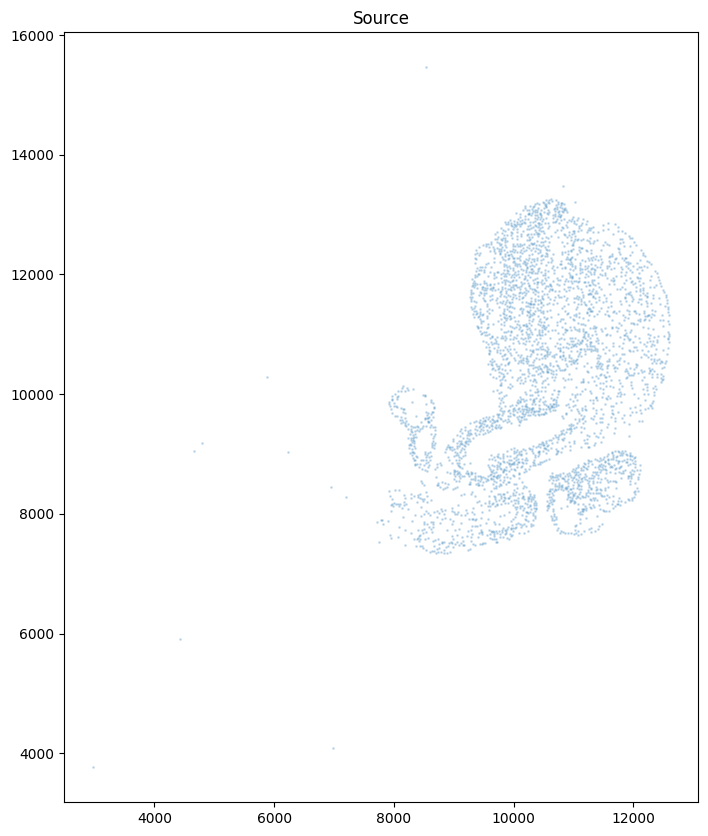

In [4]:
# Plot source
fig, ax = plt.subplots()
ax.scatter(adata_source.obsm['spatial'][:, 0],
           adata_source.obsm['spatial'][:, 1],
           s=1, alpha=0.2)
ax.set_title('Source')
ax.set_aspect('equal')

## Load target data

In [5]:
# Single cell data 2
fname = '../heart_data/4_CN73_C2.csv.gz'
df2 = pd.read_csv(fname, skiprows=[1])
print(df2.head())

   Unnamed: 0            x             y   intensity  area  id    color  \
0       27561  8411.487305  16145.589844  170.434784    52 NaN  #000000   
1       27562  8572.000000  16053.444336  160.538467    24 NaN  #000000   
2       27563  5272.444336  15628.444336  167.750000    42 NaN  #000000   
3       27564  8577.416992  15178.750000  157.199997    32 NaN  #000000   
4       27565  6675.083496  15168.583008  161.800003    32 NaN  #000000   

  acronym  right.left  rostral.caudal  spot.id    image  
0     NaN  106.791747      705.649295      NaN  CN73_C2  
1     NaN  116.291280      700.149024      NaN  CN73_C2  
2     NaN  -92.698440      662.647180      NaN  CN73_C2  
3     NaN   98.792141      647.646442      NaN  CN73_C2  
4     NaN  -23.701834      640.646097     95.0  CN73_C2  


In [6]:
# Create AnnData for target
coords_target = np.column_stack([df2['x'].values, df2['y'].values])
adata_target = ad.AnnData(
    X=np.zeros((len(coords_target), 1)),
    obs=df2,
)
adata_target.obsm['spatial'] = coords_target
print(f"Target: {adata_target.n_obs} cells")

Target: 3387 cells


/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


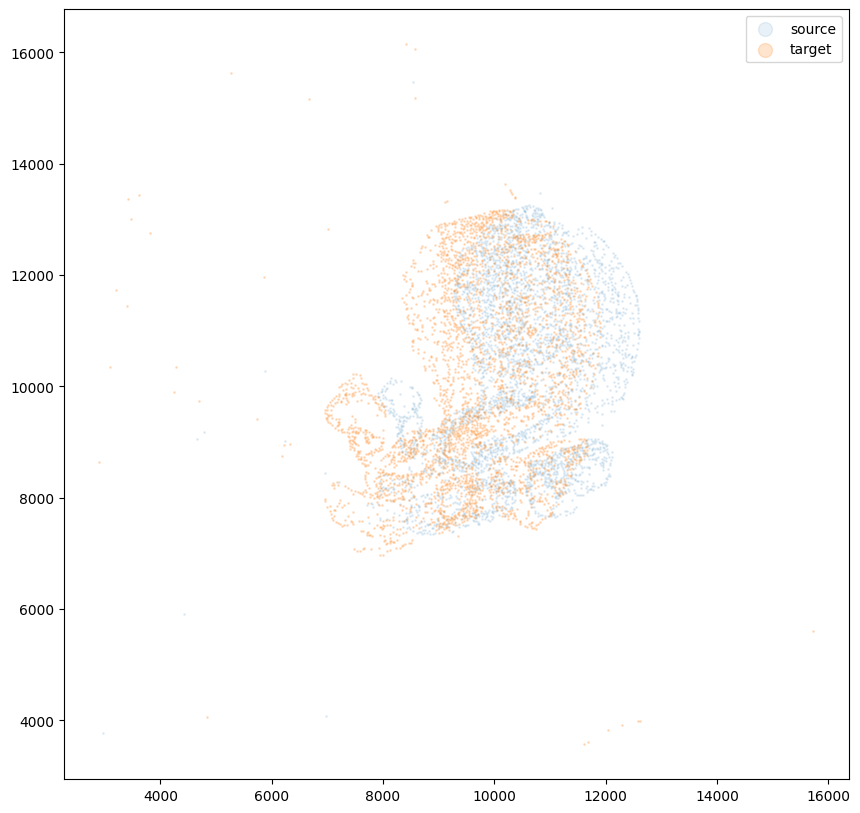

In [7]:
# Plot both before alignment
fig, ax = plt.subplots()
ax.scatter(adata_source.obsm['spatial'][:, 0],
           adata_source.obsm['spatial'][:, 1],
           s=1, alpha=0.1, label='source')
ax.scatter(adata_target.obsm['spatial'][:, 0],
           adata_target.obsm['spatial'][:, 1],
           s=1, alpha=0.2, label='target')
ax.legend(markerscale=10)
ax.set_aspect('equal')

## Align using moscot (optimal transport)

`sq.experimental.tl.align` automatically selects the moscot backend for point-to-point alignment. Moscot uses optimal transport to find a soft correspondence between the two point clouds.

In [ ]:
# Align source to target using moscot (linear OT / Sinkhorn)
sq.experimental.tl.align(
    adata_source, adata_target,
    method='optimal_transport',
    moscot_kwargs={
        'solve_kwargs': {'epsilon': 1e-1,},
        'align_kwargs': {'mode': 'affine'},
    },
)

[moscot] Combined AnnData: 6992 cells (3605 source + 3387 target)
[moscot] Solving linear optimal-transport (Sinkhorn) ...
INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(3605, 3387)].                                          


/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


[moscot] Computing aligned coordinates (mode='affine') ...
[moscot] Aligned coordinates stored in obsm['spatial_aligned']


## Visualize results

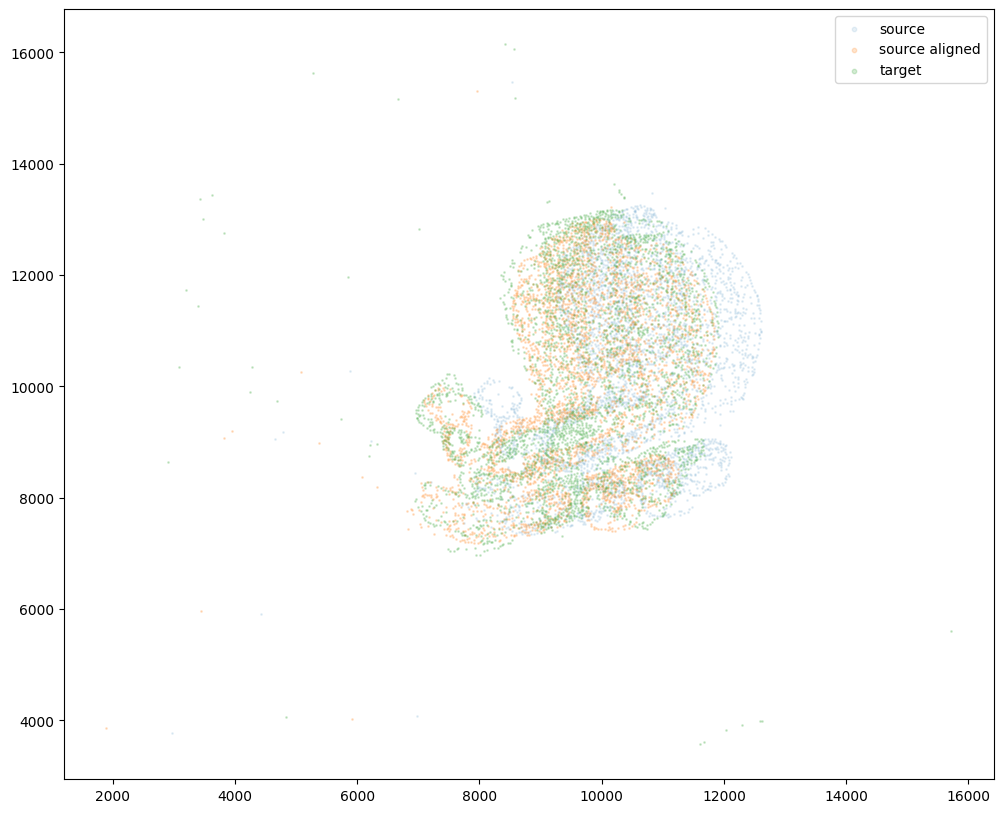

In [10]:
# Plot results
aligned = adata_source.obsm['spatial_aligned']

fig, ax = plt.subplots()
ax.scatter(adata_source.obsm['spatial'][:, 0],
           adata_source.obsm['spatial'][:, 1],
           s=1, alpha=0.1, label='source')
ax.scatter(aligned[:, 0], aligned[:, 1],
           s=1, alpha=0.2, label='source aligned')
ax.scatter(adata_target.obsm['spatial'][:, 0],
           adata_target.obsm['spatial'][:, 1],
           s=1, alpha=0.2, label='target')

lgnd = plt.legend(loc='upper right', scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])

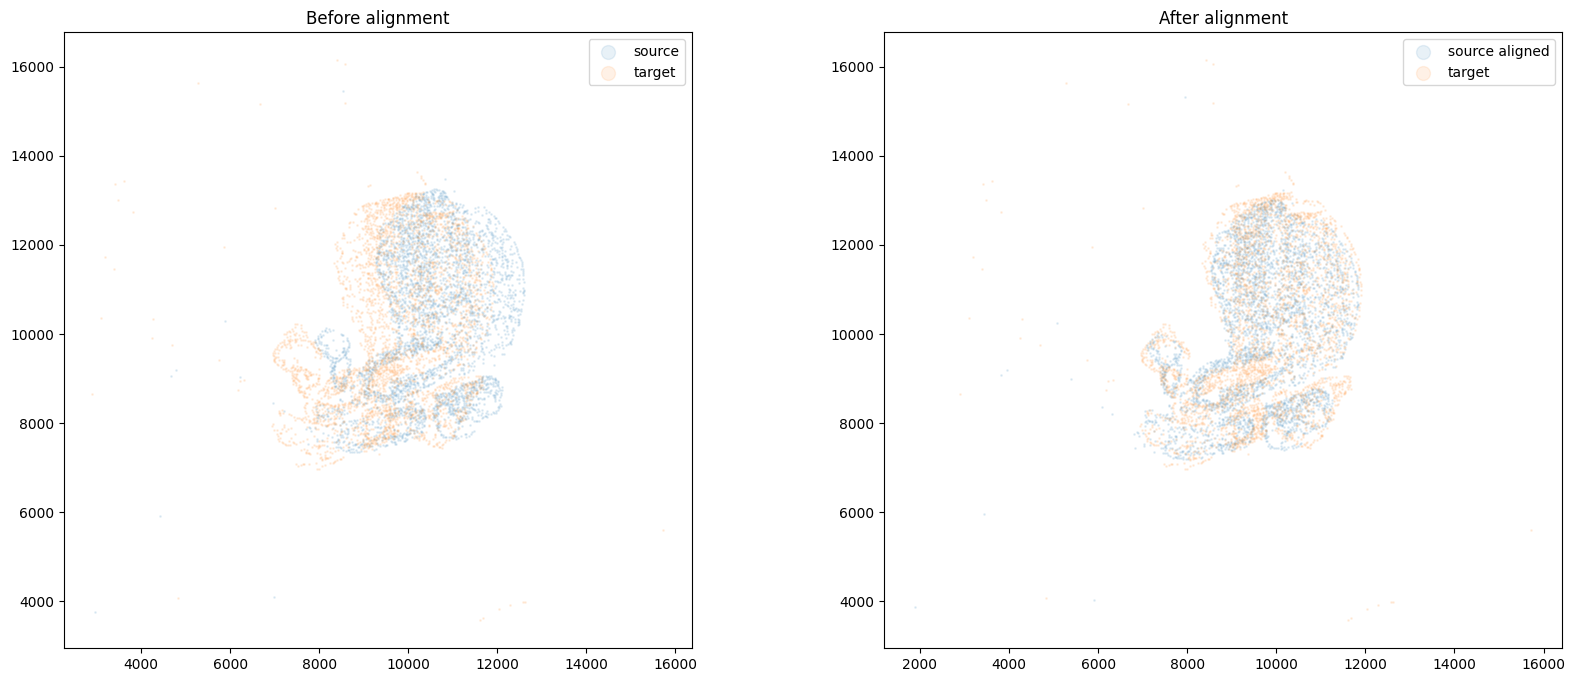

In [11]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].scatter(adata_source.obsm['spatial'][:, 0],
                adata_source.obsm['spatial'][:, 1],
                s=1, alpha=0.1, label='source')
axes[0].scatter(adata_target.obsm['spatial'][:, 0],
                adata_target.obsm['spatial'][:, 1],
                s=1, alpha=0.1, label='target')
axes[0].set_title('Before alignment')
axes[0].legend(markerscale=10)
axes[0].set_aspect('equal')

axes[1].scatter(aligned[:, 0], aligned[:, 1],
                s=1, alpha=0.1, label='source aligned')
axes[1].scatter(adata_target.obsm['spatial'][:, 0],
                adata_target.obsm['spatial'][:, 1],
                s=1, alpha=0.1, label='target')
axes[1].set_title('After alignment')
axes[1].legend(markerscale=10)
axes[1].set_aspect('equal')

In [ ]:
# Check alignment metadata
print(adata_source.uns['spatial_alignment'])

{'method': 'optimal_transport', 'backend': 'moscot', 'spatial_key': 'spatial', 'mode': 'affine'}
